<a href="https://colab.research.google.com/github/riccardogs/PyTorch_tutorial/blob/main/Datasets_DataLoaders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Code for processing data samples can get messy and hard to maintain; we ideally want our dataset code to be decoupled from our model training code for better readability and modularity. PyTorch provides two data primitives:

- torch.utils.data.DataLoader : wraps an iterable around the Dataset to enable easy access to the samples
- torch.utils.data.Dataset : stores the samples and their corresponding labels

that allow you to use pre-loaded datasets as well as your own data.


PyTorch domain libraries provide a number of pre-loaded datasets (such as FashionMNIST) that subclass torch.utils.data.Dataset and implement functions specific to the particular data. They can be used to prototype and benchmark your model. You can find them here: Image Datasets, Text Datasets, and Audio Datasets

# Loading a Dataset

Here is an example of how to load the Fashion-MNIST dataset from TorchVision.

Fashion-MNIST is a dataset of Zalando’s article images consisting of 60,000 training examples and 10,000 test examples. Each example comprises a 28×28 grayscale image and an associated label from one of 10 classes.

We load the FashionMNIST Dataset with the following parameters:
- root is the path where the train/test data is stored,
- train specifies training or test dataset,
- ' download = True ' downloads the data from the internet if it’s not available at root.
- transform and target_transform specify the feature and label transformations

In [2]:
import torch
# import torch: importa la libreria principale di PyTorch
# - Fornisce tensor, operazioni, autograd, ecc.

from torch.utils.data import Dataset
# from torch.utils.data import Dataset: importa la classe base Dataset
# - Dataset è una classe astratta che rappresenta un dataset
# - Tutti i dataset personalizzati devono ereditare da questa classe
# - Definisce i metodi __len__ e __getitem__ che devono essere implementati

from torchvision import datasets
# from torchvision import datasets: importa il modulo datasets di torchvision
# - torchvision è un pacchetto di PyTorch per la computer vision
# - datasets contiene dataset predefiniti e pronti all'uso (MNIST, CIFAR, FashionMNIST, ecc.)
# - Fornisce accesso facilitato a dataset famosi senza doverli scaricare manualmente

from torchvision.transforms import ToTensor
# from torchvision.transforms import ToTensor: importa la trasformazione ToTensor
# - ToTensor è una trasformazione che converte immagini PIL o numpy array in tensor PyTorch
# - Normalizza automaticamente i valori dei pixel da [0, 255] a [0.0, 1.0]
# - Cambia l'ordine delle dimensioni da (H, W, C) a (C, H, W) per PyTorch

import matplotlib.pyplot as plt
# import matplotlib.pyplot as plt: importa il modulo pyplot di matplotlib
# - matplotlib è la libreria principale per visualizzazione grafica in Python
# - pyplot fornisce un'interfaccia simile a MATLAB per creare grafici
# - plt è l'alias convenzionale
# - Servirà per visualizzare le immagini del dataset

In [3]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
# training_data = datasets.FashionMNIST(...): carica il dataset Fashion-MNIST per training
# - datasets.FashionMNIST: è il dataset di moda (10 categorie di abbigliamento)
#   * 60.000 immagini per training, 10.000 per test
#   * Ogni immagine è in scala di grigi 28x28 pixel
#   * 10 classi: T-shirt, pantaloni, maglioni, vestiti, cappotti, ecc.

# Parametri:
# - root="data": directory dove salvare/scaricare il dataset
#   * Crea una cartella "data" nella directory corrente
#   * I dati verranno salvati lì

# - train=True: carica il set di addestramento (training set)
#   * True = 60.000 immagini di training
#   * False = 10.000 immagini di test

# - download=True: scarica il dataset se non è già presente
#   * Se i dati non esistono in root, li scarica da Internet
#   * Se già scaricati, non li scarica di nuovo

# - transform=ToTensor(): applica la trasformazione ToTensor a ogni immagine
#   * Converte le immagini PIL in tensor PyTorch
#   * Normalizza i pixel da 0-255 a 0.0-1.0
#   * Riordina le dimensioni da (28, 28) a (1, 28, 28) - canale, altezza, larghezza

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)
# test_data = datasets.FashionMNIST(...): carica il dataset Fashion-MNIST per test
# - train=False: carica il set di test (10.000 immagini)
# - Stessi parametri di root, download e transform del training set
# - I dati di test sono separati e non vengono usati durante l'addestramento
# - Servono per valutare le prestazioni del modello su dati mai visti

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 267kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.99MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.4MB/s]


# Iterating and Visualizing the Dataset

We can index (indicizzare) Datasets manually like a list: training_data[index]. We use matplotlib to visualize some samples in our training data.


Plotta 9 immagini casuali

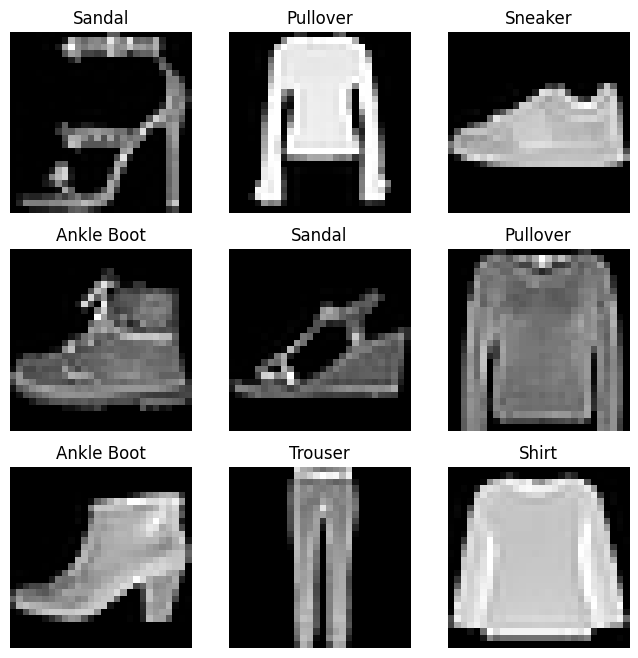

In [6]:
# La suddivisione delle label è interna al dataset fornito
# - Fashion-MNIST è un dataset pre-organizzato con 10 classi predefinite
# - Le label (0-9) sono già assegnate a specifici capi di abbigliamento
# - Questa mappatura è fissa e standard per tutti gli utenti

labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
# labels_map = {...}: crea un dizionario Python che mappa gli indici delle classi ai nomi
# - È un dizionario (mappa) con:
#   * chiave: numero intero da 0 a 9 (le 10 classi di Fashion-MNIST)
#   * valore: stringa con il nome del capo di abbigliamento in inglese
# - Serve per convertire l'etichetta numerica (es. 0) in testo leggibile ("T-Shirt")

figure = plt.figure(figsize=(8, 8))
# figure = plt.figure(figsize=(8, 8)): crea una nuova figura matplotlib
# - plt.figure(): funzione che crea una nuova figura (contenitore per grafici)
# - figsize=(8, 8): specifica le dimensioni della figura in pollici (larghezza 8, altezza 8)
# - La figura conterrà tutti i sottografici che creeremo

cols, rows = 3, 3
# cols, rows = 3, 3: definisce il numero di colonne e righe per la griglia di immagini
# - cols = 3: 3 colonne
# - rows = 3: 3 righe
# - Totale: 3×3 = 9 immagini da visualizzare

for i in range(1, cols * rows + 1):
# for i in range(1, cols * rows + 1): ciclo da 1 a 9 (incluso)
# - range(1, 10) genera numeri da 1 a 9
# - i rappresenta la posizione del sottografico nella griglia (da 1 a 9)
# - In matplotlib, i sottografici sono numerati da 1 in poi
# - range(1, N) genera numeri fino a N-1

    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    # sample_idx = torch.randint(len(training_data), size=(1,)).item(): seleziona un indice casuale
    # - torch.randint(low=0, high, size): genera numeri interi casuali
    #   * len(training_data) = 60000 (dimensione del dataset)
    #   * size=(1,): genera un tensor con un singolo numero casuale
    #   * Il numero sarà tra 0 e 59999
    # - .item(): estrae il valore come intero Python dal tensor

    img, label = training_data[sample_idx]
    # img, label = training_data[sample_idx]: recupera l'immagine e l'etichetta all'indice casuale
    # - training_data[sample_idx]: accede all'elemento sample_idx del dataset
    # - Restituisce una tupla (immagine, etichetta)
    # - img: è un tensor PyTorch di forma (1, 28, 28) [1 canale, 28 altezza, 28 larghezza]
    # - label: è un intero (0-9) che rappresenta la classe

    figure.add_subplot(rows, cols, i)
    # figure.add_subplot(rows, cols, i): aggiunge un sottografico alla figura
    # - rows, cols: griglia 3×3
    # - i: posizione corrente (da 1 a 9)
    # - Divide la figura in una griglia e seleziona la cella i-esima

    plt.title(labels_map[label])
    # plt.title(labels_map[label]): imposta il titolo del sottografico corrente
    # - labels_map[label]: converte il numero dell'etichetta (es. 5) nel nome ("Sandal")
    # - Mostra il nome del capo sopra l'immagine

    plt.axis("off")
    # plt.axis("off"): rimuove gli assi (ticks e etichette) dal sottografico
    # - Mostra solo l'immagine senza cornice, numeri, o assi

    plt.imshow(img.squeeze(), cmap="gray")
    # plt.imshow(img.squeeze(), cmap="gray"): visualizza l'immagine
    # - img.squeeze(): rimuove le dimensioni di dimensione 1
    #   * img ha shape (1, 28, 28) → .squeeze() → (28, 28)
    #   * Necessario perché imshow vuole immagini 2D (H, W), non (C, H, W)
    # - cmap="gray": specifica che la mappa di colori è in scala di grigi
    #   * Le immagini Fashion-MNIST sono in bianco e nero

plt.show()
# plt.show(): visualizza la figura con tutti i sottografici
# - Apre una finestra o mostra nel notebook le 9 immagini con i loro titoli

# Creating a Custom Dataset for your files

A custom Dataset class must implement three functions:
- __ init __
- __ len __
- __ getitem __

The FashionMNIST images are stored in a directory img_dir, and their labels are stored separately in a CSV file annotations_file.


In [7]:
import os
# import os: importa il modulo os per operazioni di sistema
# - Serve per manipolare percorsi di file e directory

import pandas as pd
# import pandas as pd: importa pandas per manipolare dati tabellari
# - Utile per leggere file di annotazioni (etichette)

from torchvision.io import decode_image
# from torchvision.io import decode_image: importa funzione per decodificare immagini
# - decode_image() legge e decodifica un'immagine dal disco in un tensor PyTorch
# - Supporta vari formati (JPEG, PNG, ecc.)

class CustomImageDataset(Dataset):
    # class CustomImageDataset(Dataset): definisce una classe che eredita da Dataset
    # - Dataset è la classe base astratta di PyTorch
    # - CustomImageDataset è il nostro dataset personalizzato per immagini
    # - Deve implementare __init__, __len__, e __getitem__

    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        # __init__: costruttore della classe: viene chiamato per prendere dati e impachettarli nell'oggetto che apparterrà a quella classe,
        # inizializza il dataset
        # Parametri:
        # - self: è il riferimento all'OGGETTO STESSO all'interno della classe
        # - annotations_file: percorso del file CSV con annotazioni
        # - img_dir: directory dove sono salvate le immagini
        # - transform: trasformazioni da applicare alle immagini (opzionale)
        # - target_transform: trasformazioni da applicare alle etichette (opzionale)

        self.img_labels = pd.read_csv(annotations_file)
        # self.img_labels = pd.read_csv(annotations_file): legge il file CSV
        # - Crea un DataFrame pandas con le annotazioni
        # - Tipicamente ha colonne: nome_file, etichetta
        # - self.img_labels è un attributo dell'istanza
        # quindi self è il dato che si sta creando, in annotation c'è annotazioni di interessi,
        # read legge quelle annotazioni e le salva in img che è attributo del self oggetto generico per ora

        self.img_dir = img_dir
        # self.img_dir = img_dir: salva il percorso della directory immagini
        # - Sarà usato per costruire i percorsi completi delle immagini

        self.transform = transform
        # self.transform = transform: salva le trasformazioni per le immagini
        # - Esempi: ToTensor(), Resize, RandomCrop, Normalize

        self.target_transform = target_transform
        # self.target_transform = target_transform: salva trasformazioni per le etichette
        # - Esempi: conversione in intero, one-hot encoding

    def __len__(self):
        # __len__: metodo chiamato da len(dataset)
        # Deve restituire il numero totale di campioni nel dataset

        return len(self.img_labels)
        # return len(self.img_labels): restituisce il numero di righe nel CSV
        # - Ogni riga corrisponde a un'immagine/etichetta

    def __getitem__(self, idx):
        # __getitem__: metodo chiamato per accedere a un elemento con dataset[idx]
        # - idx: indice dell'elemento richiesto (0, 1, 2, ...)
        # Deve restituire una tupla (immagine, etichetta) per l'indice idx

        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        # img_path = os.path.join(...): costruisce il percorso completo dell'immagine
        # - self.img_dir: directory base delle immagini
        # - self.img_labels.iloc[idx, 0]: prende il valore alla riga idx, colonna 0
        #   * Assumiamo che colonna 0 contenga il nome del file immagine
        # - os.path.join unisce in modo corretto per il SO (con / o \)

        image = decode_image(img_path)
        # image = decode_image(img_path): carica e decodifica l'immagine
        # - Legge il file dal disco
        # - Restituisce un tensor PyTorch con i pixel dell'immagine
        # - Formato tipico: (C, H, W) con C=3 per RGB, C=1 per scala di grigi

        label = self.img_labels.iloc[idx, 1]
        # label = self.img_labels.iloc[idx, 1]: prende l'etichetta alla riga idx, colonna 1
        # - Assumiamo che colonna 1 contenga l'etichetta (es. 0, 1, 2 o "gatto", "cane")

        if self.transform:
            image = self.transform(image)
            # if self.transform: se sono state specificate trasformazioni per immagini
            # image = self.transform(image): applica le trasformazioni all'immagine
            # - Es. convertire a float, normalizzare, fare data augmentation

        if self.target_transform:
            label = self.target_transform(label)
            # if self.target_transform: se sono state specificate trasformazioni per etichette
            # label = self.target_transform(label): applica trasformazioni all'etichetta
            # - Es. convertire stringa in numero intero

        return image, label
        # return image, label: restituisce la coppia (immagine elaborata, etichetta elaborata)
        # - Questo è ciò che riceveremo quando faremo dataset[idx]

# __ init __

The __ init __ function is run once when instantiating the Dataset object. We initialize the directory containing the images, the annotations file, and both transforms (covered in more detail in the next section).

The labels.csv file looks like:

In [8]:
# I TUOI DATI DI ESEMPIO NEL FILE CSV:
# tshirt1.jpg, 0
# tshirt2.jpg, 0
# ...
# ankleboot999.jpg, 9

def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
    # __init__ è il costruttore che riceve:
    # - annotations_file: il percorso del file CSV (es. "train.csv")
    # - img_dir: la cartella dove stanno le immagini (es. "images/")
    # - transform: trasformazioni per le immagini (es. ridimensionare)
    # - target_transform: trasformazioni per le etichette (es. one-hot encoding)

    self.img_labels = pd.read_csv(annotations_file)
    # pd.read_csv("train.csv") legge il file e crea una tabella come questa:
    #
    #   0             1
    #   tshirt1.jpg   0
    #   tshirt2.jpg   0
    #   ...           ...
    #   ankleboot999.jpg 9
    #
    # Questa tabella viene salvata in self.img_labels (dentro l'oggetto)

    self.img_dir = img_dir
    # self.img_dir = "images/"  (la cartella dove cercare i file)

    self.transform = transform
    # self.transform = ...  (es. una funzione che ridimensiona le immagini)

    self.target_transform = target_transform
    # self.target_transform = ...  (es. una funzione che converte 0 in [1,0,0,...])

# COSA CONTIENE ORA L'OGGETTO (self):
# - self.img_labels: la tabella con nomi file e etichette
# - self.img_dir: la cartella "images/"
# - self.transform: la funzione di trasformazione (se fornita)
# - self.target_transform: la funzione per etichette (se fornita)

# Quando dopo chiameremo __getitem__(self, 0):
# - Prenderà self.img_labels.iloc[0, 0] → "tshirt1.jpg"
# - Costruirà il percorso: self.img_dir + "tshirt1.jpg" → "images/tshirt1.jpg"
# - Prenderà self.img_labels.iloc[0, 1] → 0 (etichetta)
# - Applicherà le trasformazioni
# - Restituirà (immagine, etichetta)

# __len __

The __len __ function returns the number of samples in our dataset.

Example:

In [9]:
def __len__(self):
    return len(self.img_labels)

# __getitem __

The __getitem __ function loads and returns a sample from the dataset at the given index idx.

Based on the index, it identifies the image’s location on disk, converts that to a tensor using decode_image, retrieves the corresponding label from the csv data in self.img_labels, calls the transform functions on them (if applicable), and returns the tensor image and corresponding label in a tuple.

In [10]:
def __getitem__(self, idx):
    # __getitem__: metodo speciale che permette di accedere a un elemento con dataset[idx]
    # - Viene chiamato automaticamente quando fai: mio_dataset[5]
    # - self: l'oggetto dataset stesso
    # - idx: l'indice dell'elemento richiesto (es. 0, 1, 2, ..., 59999)

    img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
    # img_path = costruisce il percorso completo del file immagine
    # - self.img_dir: la cartella base (es. "data/images/")
    # - self.img_labels.iloc[idx, 0]: prende il valore alla riga idx, colonna 0
    #   * iloc = "integer location" (posizione intera)
    #   * colonna 0 contiene il nome del file (es. "tshirt1.jpg")
    # - os.path.join unisce le parti con lo slash giusto per il sistema operativo
    #   * Windows: "data/images\\tshirt1.jpg"
    #   * Linux/Mac: "data/images/tshirt1.jpg"

    image = decode_image(img_path)
    # image = decode_image(img_path): carica l'immagine dal disco
    # - Apre il file all'indirizzo img_path
    # - Legge i pixel dell'immagine
    # - Converte in un tensor PyTorch
    # - Il tensor avrà forma (C, H, W) dove:
    #   * C = canali (1 per scala di grigi, 3 per RGB)
    #   * H = altezza in pixel
    #   * W = larghezza in pixel

    label = self.img_labels.iloc[idx, 1]
    # label = self.img_labels.iloc[idx, 1]: prende l'etichetta alla riga idx, colonna 1
    # - colonna 1 contiene il numero della classe (es. 0, 1, 2, ..., 9)
    # - Per Fashion-MNIST, 0 = T-shirt, 1 = Trouser, ecc.

    if self.transform:
        # if self.transform: verifica se sono state fornite trasformazioni per le immagini
        image = self.transform(image)
        # Applica le trasformazioni all'immagine
        # - Esempi: ridimensionare, normalizzare, fare data augmentation
        # - trasforma l'immagine nel formato desiderato per il modello

    if self.target_transform:
        # if self.target_transform: verifica se sono state fornite trasformazioni per le etichette
        label = self.target_transform(label)
        # Applica le trasformazioni all'etichetta
        # - Esempi: convertire in tensor, one-hot encoding

    return image, label
    # return image, label: restituisce una tupla con (immagine elaborata, etichetta elaborata)
    # - Questo è ciò che ottieni quando fai dataset[0]
    # - Pronto per essere usato dal modello o dal DataLoader

# Preparing your data for training with DataLoaders

The Dataset retrieves our dataset’s features and labels one sample at a time. While training a model, we typically want to pass samples in “minibatches”, reshuffle the data at every epoch to reduce model overfitting, and use Python’s multiprocessing to speed up data retrieval.

DataLoader is an iterable that abstracts this complexity for us in an easy API.

In [12]:
from torch.utils.data import DataLoader
# from torch.utils.data import DataLoader: importa la classe DataLoader
# - torch.utils.data: sottopacchetto di PyTorch per la gestione dei dati
# - DataLoader: è uno strumento che:
#   * Carica i dati in batch (gruppi)
#   * Gestisce lo shuffling (mescolamento)
#   * Permette caricamento parallelo con più worker
#   * Iterare sui dati in modo efficiente

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
# train_dataloader = DataLoader(...): crea un DataLoader per il training set
# - training_data: il dataset Fashion-MNIST che abbiamo caricato prima (60.000 immagini)
# - batch_size=64: ogni batch conterrà 64 immagini
#      Immagina di dover mostrare 60.000 foto a una persona per imparare a riconoscere vestiti
#      - Mostrarle tutte insieme è impossibile (troppe informazioni)
#      - Mostrarle una alla volta è lento (60.000 passaggi)
#   Il BATCH è un "gruppetto" di immagini processate insieme:
#      - Invece di 1 immagine alla volta, ne prendi 64
#      - Invece di tutte e 60.000 insieme, le dividi in tanti gruppi da 64
#   * Con 60.000 immagini, avremo 60.000 / 64 = circa 938 batch
#   * L'ultimo batch potrebbe essere più piccolo se non divisibile

# - shuffle=True: mescola i dati a ogni epoca (importante per il training)
#   * Evita che il modello impari l'ordine dei dati
#   * Garantisce che ogni batch sia una buona rappresentazione del dataset

test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)
# test_dataloader = DataLoader(...): crea un DataLoader per il test set
# - test_data: il dataset di test (10.000 immagini)
# - batch_size=64: anche qui batch da 64 immagini
#   * 10.000 / 64 = circa 157 batch
# - shuffle=True: mescola anche i dati di test
#   * Anche se per la valutazione spesso non è necessario mescolare
#   * A volte si usa shuffle=False per valutazioni consistenti

# COSA PRODUCE QUESTO CODICE:
# train_dataloader è un oggetto su cui possiamo iterare:
# for batch in train_dataloader:
#     images, labels = batch
#     # images ha shape: (64, 1, 28, 28) - 64 immagini, 1 canale, 28x28 pixel
#     # labels ha shape: (64,) - 64 etichette corrispondenti

# VANTAGGI DEL DATALOADER:
# - Non carica TUTTE le 60.000 immagini in memoria contemporaneamente
# - Carica solo un batch alla volta (64 immagini)
# - Durante il training, presenta i dati in ordine casuale ogni epoca
# - Può caricare in parallelo su più processi (num_workers)

# Iterate through the DataLoader

We have loaded that dataset into the DataLoader and can iterate through the dataset as needed. Each iteration below returns a batch of train_features and train_labels (containing batch_size=64 features and labels respectively). Because we specified shuffle=True, after we iterate over all batches the data is shuffled (for finer-grained control over the data loading order, take a look at Samplers).


Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


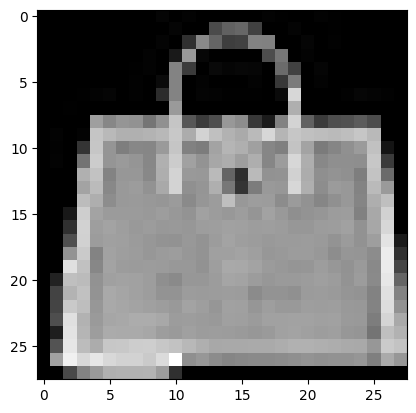

Label: 8


In [14]:
# Display image and label

train_features, train_labels = next(iter(train_dataloader))
# train_features, train_labels = next(iter(train_dataloader)): prende un batch dal dataloader
# - iter(train_dataloader): crea un iteratore sul dataloader
# - next(): prende il prossimo elemento dall'iteratore (il primo batch)
# - train_features: contiene le immagini del batch (64 immagini)
# - train_labels: contiene le etichette corrispondenti (64 etichette)
# - Questo è come fare "dammi il primo batch di dati"

print(f"Feature batch shape: {train_features.size()}")
# print(f"Feature batch shape: {train_features.size()}"): stampa la forma del batch di immagini
# - train_features.size() restituisce torch.Size([64, 1, 28, 28])
#   * 64: numero di immagini nel batch
#   * 1: numero di canali (1 = scala di grigi)
#   * 28: altezza in pixel
#   * 28: larghezza in pixel
# - Output: "Feature batch shape: torch.Size([64, 1, 28, 28])"

print(f"Labels batch shape: {train_labels.size()}")
# print(f"Labels batch shape: {train_labels.size()}"): stampa la forma del batch di etichette
# - train_labels.size() restituisce torch.Size([64])
#   * 64: vettore con 64 etichette (una per ogni immagine)
# - Output: "Labels batch shape: torch.Size([64])"

img = train_features[0].squeeze()
# img = train_features[0].squeeze(): estrae la prima immagine del batch e rimuove dimensioni inutili
# - train_features[0]: prende la prima immagine del batch (indice 0)
#   * Ha forma (1, 28, 28) - 1 canale, 28x28 pixel
# - .squeeze(): rimuove le dimensioni di dimensione 1
#   * Da (1, 28, 28) a (28, 28)
#   * Necessario perché plt.imshow vuole immagini 2D (altezza, larghezza)
# - Ora img è un tensor 2D di forma (28, 28)

label = train_labels[0]
# label = train_labels[0]: prende la prima etichetta del batch
# - train_labels[0] è un numero (es. tensor(5))
# - Corrisponde all'etichetta della prima immagine

plt.imshow(img, cmap="gray")
# plt.imshow(img, cmap="gray"): visualizza l'immagine
# - img: il tensor 2D (28, 28) con i valori dei pixel
# - cmap="gray": usa una mappa di colori in scala di grigi
# - Mostra l'immagine in bianco e nero

plt.show()
# plt.show(): effettivamente visualizza la figura creata

print(f"Label: {label}")
# print(f"Label: {label}"): stampa il valore dell'etichetta
# - Mostra il numero della classe (es. "Label: 5")
# - 5 corrisponde a "Sandal" (sandalo) nella mappa labels_map di prima